## 1. The Adaptive Exponential Integrate-and-Fire (Ad-Ex) neuron model

Tutor: Ariel Shmilli [<span>&#9993;</span>](mailto:a.shmilli@sussex.ac.uk)

This notebook is based on the [NESTML Adaptive Exponential Integrate-and-Fire (Ad-Ex) neuron model](https://github.com/nest/nestml/blob/main/models/neurons/aeif_cond_alpha_neuron.nestml) (credit to: Charl Linssen and Pooja Babu) and was adapted by Ariel Shmilli for the ...

---

In this Jupyter Notebook we will write from scratch the Adaptive Exponential
Integrate-and-Fire (AdEx) neuron model [[1]](https://pubmed.ncbi.nlm.nih.gov/16014787/) in NESTML, build it, and use it in
a simple NEST simulation to explore the range of firing dynamics this model can
reproduce.

The AdEx neuron is described by the following set of equations:

$$
\begin{cases}
    C \frac{dV}{dt} = -g_L(V - E_L) + g_L \Delta_T \exp\!\left(\frac{V - V_T}{\Delta_T}\right) - w + I \\[6pt]
    \tau_w \frac{dw}{dt} = a(V - E_L) - w
\end{cases}
$$

Where $V$ is the membrane potential and $w$ is the adaptation current.
The first equation extends the standard Leaky Integrate-and-Fire model with an
exponential nonlinearity: as $V$ approaches the effective threshold $V_T$, the
exponential term drives a rapid upswing that mimics the onset of a real action
potential. The second equation describes a slow adaptation current that provides
negative feedback to $V$ on longer timescales.

When the membrane potential reaches a cutoff value $V_\text{peak}$, the
variables are reset following:

$$
\begin{cases}
    V \leftarrow V_r \\
    w \leftarrow w + b
\end{cases}
$$

The model parameters and their roles are:

- $C$ — membrane capacitance
- $g_L$ — leak conductance
- $E_L$ — resting (leak reversal) potential
- $\Delta_T$ — slope factor controlling the sharpness of spike initiation
- $V_T$ — effective threshold potential (where the exponential activates)
- $\tau_w$ — adaptation time constant
- $a$ — subthreshold adaptation coupling (conductance between $V$ and $w$)
- $b$ — spike-triggered adaptation increment
- $V_r$ — reset potential after a spike

The AdEx model is a conceptual hybrid: it combines the biophysically motivated
exponential spike initiation [[2]](https://pubmed.ncbi.nlm.nih.gov/14684865/) with the two-variable
adaptation structure of the Izhikevich model [[3]](https://pubmed.ncbi.nlm.nih.gov/18244602/). By tuning $a$, $b$, $\tau_w$,
and the reset parameters, it can reproduce a wide range of cortical firing patterns
while keeping the parameter set small and physiologically interpretable.

A key advantage of the AdEx is that all parameters have clear biophysical meaning
and can in principle be estimated from standard current-clamp protocols (step and
ramp current injections). Brette and Gerstner showed that with parameters fitted to
a detailed conductance-based regular spiking neuron, the AdEx correctly predicted
the timing of 96% of spikes (±2 ms) under noisy synaptic input, and was
particularly reliable in high-conductance states typical of cortical activity in vivo.

The main limitation is the non-physical blow-up of $V$ at spike time, which
requires an explicit cutoff $V_\text{peak}$ and reset rule. Compared to simpler
integrate-and-fire models, the AdEx is somewhat more expensive to simulate due to
the additional term, but remains far cheaper than full conductance-based models.


By tuning the parameters of the AdEx model, a wide variety of cortical firing
patterns can be reproduced [[4]](https://pubmed.ncbi.nlm.nih.gov/19011922/).
In this notebook we simulate four representative
regimes in response to a step current injection:

- **Adapting**: the neuron fires tonically but with progressively increasing
  interspike intervals, reflecting the build-up of the adaptation current $w$
  over time.

- **Initial bursting**: the neuron emits a burst of spikes at the beginning of
  the simulation [...]

- **Delayed accelerating**: the neuron exhibits a delayed onset of spiking
  followed by an acceleration of the firing rate, a pattern associated with
  specific combinations of subthreshold adaptation and reset parameters.

- **Irregular spiking**: the neuron fires in an aperiodic, apparently
  unpredictable manner. This regime corresponds to deterministic chaos in the
  AdEx model with the spike times sensitive to initial conditions [1].

---

### References

[1] R. Brette and W. Gerstner, "Adaptive exponential integrate-and-fire model as
an effective description of neuronal activity", *Journal of Neurophysiology*,
vol. 94, no. 5, pp. 3637–3642, Nov. 2005, doi: 10.1152/jn.00686.2005.

[2] N. Fourcaud-Trocmé, D. Hansel, C. van Vreeswijk, and N. Brunel,
"How spike generation mechanisms determine the neuronal response to fluctuating
inputs", *Journal of Neuroscience*, vol. 23, no. 37, pp. 11628–11640, Dec. 2003,
doi: 10.1523/JNEUROSCI.23-37-11628.2003.

[3] E. M. Izhikevich, "Simple model of spiking neurons", *IEEE Transactions on
Neural Networks*, vol. 14, no. 6, pp. 1569–1572, Nov. 2003,
doi: 10.1109/TNN.2003.820440.

[4] R. Naud, N. Marcille, C. Clopath, and W. Gerstner, "Firing patterns in the
adaptive exponential integrate-and-fire model", *Biological Cybernetics*,
vol. 99, no. 4–5, pp. 335–347, Nov. 2008, doi: 10.1007/s00422-008-0264-7.



### 1.2. General outline of NESTML

NESTML is a powerful and intuitive tool that allows us to define our own neuron and synapse models by writing the equations and conditions that drive their dynamics.


To define the models, NESTML requires different 'blocks', each one serving different functions:

- **Parameters**: variables that remain constant throughout the simulation.

- **Internals** (optional): constant helper variables that are derived from parameters.

- **State**: list of variables that change over time.

- **Input**: one or more input ports --> spikes or continuous inputs (e.g., currents).

- **Output**: defines which type of event the models sends (currently, only spiking output is supported).

- **Equations**: system of differential equations, with an arbitrary amount of equations, that contain derivatives of arbitrary order.

- **Update**: contains statements which are executed at every simulation steps.

- **onReceive**: excecutes conditions when spiking inputs are received to the model.

- **onCondition**: excecutes conditions (in general).


You can find more information at: https://nestml.readthedocs.io/en/latest/nestml_language/nestml_language_concepts.html

### 1.3. NESTML neuron model

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import nest
import numpy as np
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils # type: ignore
from pynestml.frontend import pynestml_frontend # pyright: ignore[reportMissingImports]

nest.set_verbosity("M_FATAL")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Apr 14 2026 11:35:50

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
neuron_model = """
model aeif_neuron:
    parameters:
        # membrane parameters
        C_m pF = 281.0 pF              # Membrane capacitance
        refr_T ms = 2 ms               # Duration of refractory period
        V_reset mV = -60.0 mV          # Reset potential
        g_L nS = 30.0 nS               # Leak conductance
        E_L mV = -70.6 mV              # Leak reversal potential (resting potential)

        # spike adaptation parameters
        a nS = 4 nS                    # Subthreshold adaptation
        b pA = 80.5 pA                 # Spike-triggered adaptation
        Delta_T mV = 2.0 mV            # Slope factor
        tau_w ms = 144.0 ms            # Adaptation time constant
        V_th mV = -50.4 mV             # Spike initiation threshold
        V_peak mV = 0 mV               # Spike detection threshold

        # synaptic parameters
        E_exc mV = 0 mV                # Excitatory reversal potential
        tau_syn_exc ms = 0.2 ms        # Synaptic time constant excitatory synapse
        E_inh mV = -85.0 mV            # Inhibitory reversal potential
        tau_syn_inh ms = 2.0 ms        # Synaptic time constant for inhibitory synapse

        # Constant external input current
        I_e pA = 0 pA

    internals:
        unit_psg nS = 1 nS    # Unitary postsynaptic conductance amplitude

    input:
        exc_spikes <- excitatory spike
        inh_spikes <- inhibitory spike
        I_stim pA <- continuous

    output:
        spike

    state:
        V_m mV = E_L        # Membrane potential
        w pA = 0 pA         # Spike-adaptation current
        refr_t ms = 0 ms    # Refractory period timer

    equations:
        inline V_bounded mV = min(V_m, V_peak) # prevent exponential divergence
        kernel g_inh = (e / tau_syn_inh) * t * exp(-t / tau_syn_inh)
        kernel g_exc = (e / tau_syn_exc) * t * exp(-t / tau_syn_exc)

        # Add inlines to simplify the equation definition of V_m
        inline I_spike pA = g_L * Delta_T * exp((V_bounded - V_th) / Delta_T)
        inline I_syn_exc pA = convolve(g_exc, exc_spikes) * (V_bounded - E_exc) * nS
        inline I_syn_inh pA = convolve(g_inh, inh_spikes) * (V_bounded - E_inh) * nS
        
        V_m' = (-g_L * (V_bounded - E_L) + I_spike - I_syn_exc - I_syn_inh - w + I_e + I_stim) / C_m
        w' = (a * (V_bounded - E_L) - w) / tau_w

        refr_t' = -1e3 * ms/s    # refractoriness is implemented as an ODE, representing a timer counting back down to zero.

    update:
        if refr_t > 0 ms:
            # neuron is absolute refractory, do not evolve V_m
            integrate_odes(w, refr_t)
        else:
            # neuron not refractory
            integrate_odes(V_m, w)

    onCondition(refr_t <= 0 ms and V_m >= V_peak):
        # threshold crossing
        refr_t = refr_T    # start of the refractory period
        V_m = V_reset
        w += b
        emit_spike()
"""

In [3]:
module_name, neuron_model_name = NESTCodeGeneratorUtils.generate_code_for(neuron_model, target_path="./model_build/adex/target")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Apr 14 2026 11:35:50

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[12,aeif_neuron_nestml, WARNING, [12:8;12:17]]: Variable 'a' has the same name as a physical unit!


### 1.4. Simulating the neuron

In [4]:
patterns_dict = {
    "Adapting": {"C_m": 200, "g_L": 12, "E_L": -70, "V_th": -50, "Delta_T": 2, "a": 2, "tau_w": 300, "b": 60, "V_reset": -58, "I_e": 500},
    "Initial burst": {"C_m": 130, "g_L": 18, "E_L": -58, "V_th": -50, "Delta_T": 2, "a": 4, "tau_w": 150, "b": 120, "V_reset": -50, "I_e": 400},
    "Delayed accelerating": {"C_m": 200, "g_L": 12, "E_L": -70, "V_th": -50, "Delta_T": 2, "a": -10, "tau_w": 300, "b": 0, "V_reset": -58, "I_e": 300},
    "Irregular": {"C_m": 100, "g_L": 12, "E_L": -60, "V_th": -50, "Delta_T": 2, "a": -11, "tau_w": 130, "b": 30, "V_reset": -48, "I_e": 160},
}

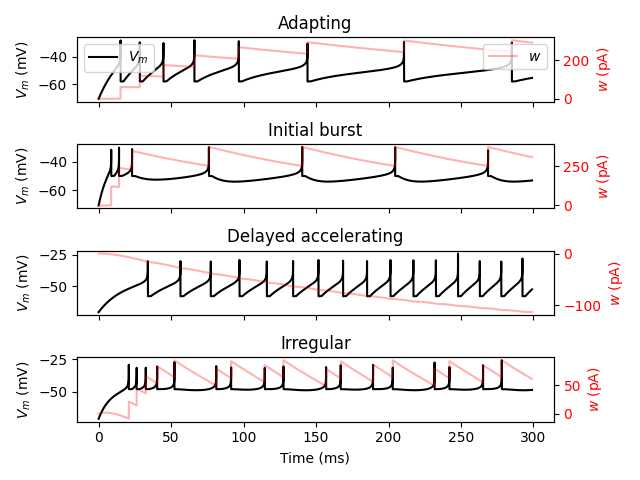

In [5]:
fig, ax = plt.subplots(len(patterns_dict), 1, sharex=True)

resolution = 0.001

for i, (pattern, neuron_params) in enumerate(patterns_dict.items()):
    nest.ResetKernel()
    nest.Install(module_name)
    nest.set(**{"resolution": resolution})

    neuron = nest.Create(neuron_model_name, params=neuron_params)
    mm = nest.Create("multimeter", params={"record_from": ["V_m", "w"], "interval": resolution})

    nest.Connect(mm, neuron)
    nest.Simulate(300)

    events = mm.get("events")

    time = events["times"]
    v = events["V_m"]
    w = events["w"]

    ax2 = ax[i].twinx()

    ax[i].plot(time, v, color="k", label="$V_m$")
    ax2.plot(time, w, color="r", label="$w$", alpha=0.3)

    ax[i].set_title(f"{pattern}")
    ax[i].set_ylabel("$V_m$ (mV)", color="k")
    ax2.set_ylabel("$w$ (pA)", color="r")
    ax[i].tick_params(axis="y", labelcolor="k")
    ax2.tick_params(axis="y", labelcolor="r")

    if i == 0:
        ax[i].legend(loc="upper left")
        ax2.legend(loc="upper right")

ax[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

---

# 2. The Tsodyks-Markram synapse model with short-term plasticity

In [6]:
synapse_model = """
model tsodyks_synapse:
    parameters:
        w real = 1            # Synaptic weight
        tau_psc ms = 3 ms
        tau_fac ms = 100 ms   # Setting tau_fac = 0 disables facilitation
        tau_rec ms = 300 ms
        U real = .5
        d ms = 1 ms

    state:
        x real = 1
        y real = 0
        u real = U
        w_tot real = 1
        t_last_update ms = 0 ms

    input:
        pre_spikes <- spike

    output:
        spike(weight real, delay ms)

    onReceive(pre_spikes):
        dt ms = t - t_last_update
        t_last_update = t

        Puu real = tau_fac == 0 ? 0 : exp(-dt / tau_fac)
        Pyy real = exp(-dt / tau_psc)
        Pzz real = exp(-dt / tau_rec)
        Pxy real = ((Pzz - 1) * tau_rec - (Pyy - 1) * tau_psc) / (tau_psc - tau_rec)
        Pxz real = 1 - Pzz
        z real = 1 - x - y

        # depress synapse
        u *= Puu
        x += Pxy * y + Pxz * z
        y *= Pyy
        u += U * (1 - u)

        delta_y_tsp real = u * x
        x -= delta_y_tsp
        y += delta_y_tsp

        w_tot = delta_y_tsp * w

        # deliver spike to postsynaptic partner
        emit_spike(w_tot, d)
"""

In [7]:
options = {"weight_variable": {"tsodyks_synapse": "w_tot"},
           "delay_variable": {"tsodyks_synapse": "d"}}

module_name, neuron_model_name, synapse_model_name = NESTCodeGeneratorUtils.generate_code_for(neuron_model,
                                                                                              synapse_model,
                                                                                              target_path="./model_build/adex_tsodyks/target",
                                                                                              post_ports=[],
                                                                                              codegen_opts=options)


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Apr 14 2026 11:35:50

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[18,tsodyks_synapse_nestml, WARNING, [28:19;28:30]]: Operands of logical comparison operator not compatible.
[20,aeif_neuron_nestml, WARNING, [12:8;12:17]]: Variable 'a' has the same name as a physical unit!
[28,tsodyks_synapse_nestml, WARNING, [9:8;9:17]]: Variable 'd' has the same name as a physical unit!


In [8]:
res = 0.1

nest.ResetKernel()
nest.Install(module_name)

patterns_dict["Adapting"]["I_e"] = 0
patterns_dict["Initial burst"]["I_e"] = 0

pre = nest.Create(neuron_model_name, n=100, params=patterns_dict["Adapting"])
post = nest.Create(neuron_model_name, params=patterns_dict["Initial burst"])
sg1 = nest.Create("poisson_generator", params={"rate": 30000, "start": 200, "stop": 1000})
sg2 = nest.Create("poisson_generator", params={"rate": 30000, "start": 1500})
mm_pre = nest.Create("multimeter", params={"record_from": ["V_m"], "interval": res})
mm_post = nest.Create("multimeter", params={"record_from": ["V_m"], "interval": res})

nest.Connect(pre, post, syn_spec={"synapse_model": synapse_model_name})
nest.Connect(sg1, pre)
nest.Connect(sg2, pre)
nest.Connect(mm_pre, pre[0])
nest.Connect(mm_post, post)

syn = nest.GetConnections(source=pre[0])

sim_time = 2000
n_steps = int(sim_time / res)

time = np.linspace(0, sim_time / 1000, n_steps)

x = np.zeros(n_steps)
y = np.zeros(n_steps)
w = np.zeros(n_steps)

for i in range(n_steps):
    nest.Simulate(res)
    vars = syn.get(["x", "y", "w_tot"])
    x[i] = vars["x"]
    y[i] = vars["y"]
    w[i] = vars["w_tot"]    

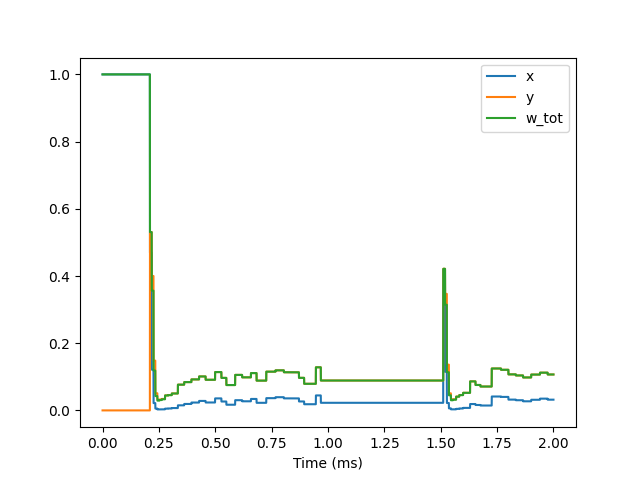

In [9]:
plt.figure()
plt.plot(time, x, label="x")
plt.plot(time, y, label="y")
plt.plot(time, w, label="w_tot")
plt.xlabel("Time (ms)")
plt.ylabel("")
plt.legend()
plt.show()

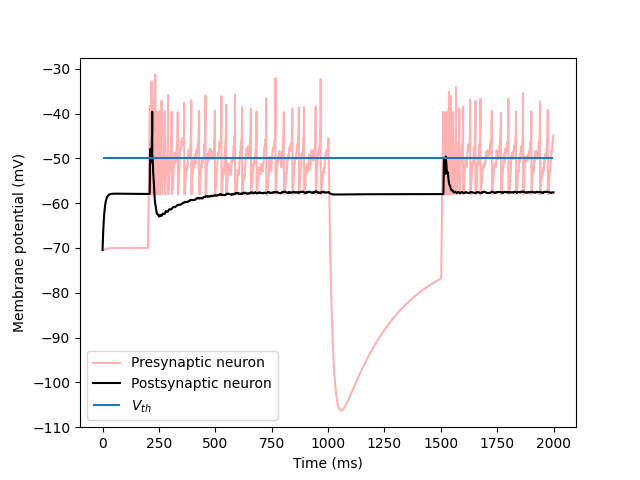

In [12]:
time_mm = mm_pre.get("events")["times"]
v_pre = mm_pre.get("events")["V_m"]
v_post = mm_post.get("events")["V_m"]

v_th = post.get("V_th")

plt.figure()
plt.plot(time_mm, v_pre, label="Presynaptic neuron", color="r", alpha=0.3)
plt.plot(time_mm, v_post, label="Postsynaptic neuron", color="k")
plt.hlines(y=v_th, xmin=time_mm[0], xmax=time_mm[-1], label="$V_{th}$")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.legend()
plt.show()